In [2]:
import pandas as pd 
import sys
sys.path.append('...')

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
from preprocessor import preprocess
X_train, X_test, y_train, y_test, feature_names, scaler = preprocess(df,'Survived')
print("✅ Preprocessing done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {len(feature_names)}")
print(f"Feature names    : {feature_names}")


✅ Preprocessing done!
Training samples : 712
Test samples     : 179
Features used    : 834
Feature names    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Ticket_110413', 'Ticket_110465', 'Ticket_110564', 'Ticket_110813', 'Ticket_111240', 'Ticket_111320', 'Ticket_111361', 'Ticket_111369', 'Ticket_111426', 'Ticket_111427', 'Ticket_111428', 'Ticket_112050', 'Ticket_112052', 'Ticket_112053', 'Ticket_112058', 'Ticket_112059', 'Ticket_112277', 'Ticket_112379', 'Ticket_113028', 'Ticket_113043', 'Ticket_113050', 'Ticket_113051', 'Ticket_113055', 'Ticket_113056', 'Ticket_113059', 'Ticket_113501', 'Ticket_113503', 'Ticket_113505', 'Ticket_113509', 'Ticket_113510', 'Ticket_113514', 'Ticket_113572', 'Ticket_113760', 'Ticket_113767', 'Ticket_113773', 'Ticket_113776', 'Ticket_113781', 'Ticket_113783', 'Ticket_113784', 'Ticket_113786', 'Ticket_113787', 'Ticket_113788', 'Ticket_113789', 'Ticket_113792', 'Ticket_113794', 'Ticket_113796', 'Ticket_113798', 'Ticket_113800', 'Ticket_113803', '

In [4]:
from test_detector import detect_task

task= detect_task(df,'Survived')
print(f"Detected task: {task}")

Detected task: classification


In [5]:
from trainer import train_all_models 

print("Training models... ")
trained_models = train_all_models(X_train, y_train, task)
print(f"\n✅ All {len(trained_models)} models trained!")

Training models... 
 Training Logistic Regression...
 Logistic Regression trained.
 Training Random_Forest...
 Random_Forest trained.
 Training XGBoost...
 XGBoost trained.
 Training SVM...
 SVM trained.
 Training KNN...
 KNN trained.

✅ All 5 models trained!


In [6]:
from evaluator import evaluate_All_models
import pandas as pd

results= evaluate_All_models(trained_models, X_test, y_test, task)

# Print as a clean table
results_df = pd.DataFrame(results)
print("Model Comparison (best to worst): \n")
print(results_df.to_string(index=False))
print(f"Best Model: {results[0]['model']} ({results[0]['accuracy']}% accuracy)")

Model Comparison (best to worst): 

              model  accuracy  f1_score  roc_auc
Logistic Regression     82.12    0.8159   0.9187
      Random_Forest     82.12    0.8167   0.8983
            XGBoost     80.45    0.8047   0.8802
                SVM     64.80    0.5643   0.8266
                KNN     45.81    0.3784   0.5419
Best Model: Logistic Regression (82.12% accuracy)


In [8]:
import sys
sys.path.append('..')

from ml_engine.pipeline import run_pipeline

df.to_csv('titanic.csv', index=False)

output = run_pipeline('titanic.csv', target_col='Survived', job_id ='test_jon_001')

# Print the results cleanly
print(f"Status     : {output['status']}")
print(f"Task       : {output['task']}")
print(f"Best model : {output['best_model']}")
print(f"Model path : {output['model_path']}")
print(f"Features   : {output['features']}")
print(f"\n📊 All Results:")
for r in output['results']:
    print(f"  {r['model']:<25} accuracy: {r['accuracy']}%")


[Pipeline] Loading dataset from titanic.csv
[Pipeline] Dataset loaded: 891 rows, 12 columns
[Pipeline]  Task detected: classification
[Pipeline] Preprocessing data...
[Pipeline] Preprocessing done - 834 features
[Pipeline] Training models...
 Training Logistic Regression...
 Logistic Regression trained.
 Training Random_Forest...
 Random_Forest trained.
 Training XGBoost...
 XGBoost trained.
 Training SVM...
 SVM trained.
 Training KNN...
 KNN trained.
[Pipeline] Evaluating models:...
[Pipeline] Best model Logistic Regression saved to storage/models\model_test_jon_001.pkl
Status     : completed
Task       : classification
Best model : Logistic Regression
Model path : storage/models\model_test_jon_001.pkl
Features   : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Ticket_110413', 'Ticket_110465', 'Ticket_110564', 'Ticket_110813', 'Ticket_111240', 'Ticket_111320', 'Ticket_111361', 'Ticket_111369', 'Ticket_111426', 'Ticket_111427', 'Ticket_111428', 'Ticket_112050', 'Ticket_11205

📋 OVERVIEW
  rows                : 891
  columns             : 12
  duplicate_rows      : 0
  total_missing       : 866
  column_names        : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

❗ MISSING VALUES
  Age            : 177 missing (19.87%)
  Cabin          : 687 missing (77.1%)
  Embarked       : 2 missing (0.22%)

📊 NUMERIC STATS
  PassengerId     mean=446.0  median=446.0  min=1.0  max=891.0
  Survived        mean=0.384  median=0.0  min=0.0  max=1.0
  Pclass          mean=2.309  median=3.0  min=1.0  max=3.0
  Age             mean=29.699  median=28.0  min=0.42  max=80.0
  SibSp           mean=0.523  median=0.0  min=0.0  max=8.0
  Parch           mean=0.382  median=0.0  min=0.0  max=6.0
  Fare            mean=32.204  median=14.454  min=0.0  max=512.329

📈 CHARTS

  → missing_values


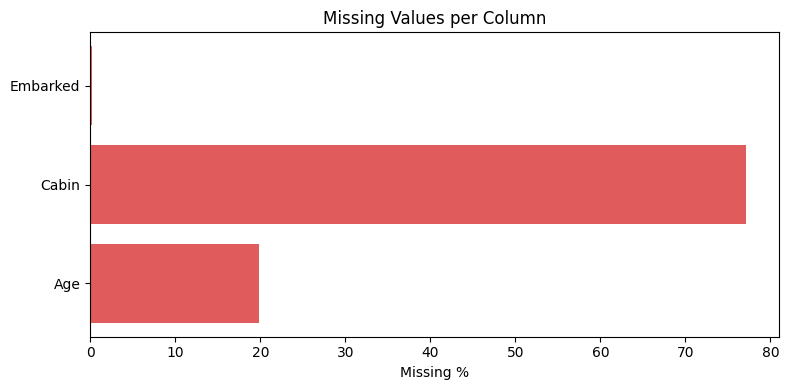


  → distributions


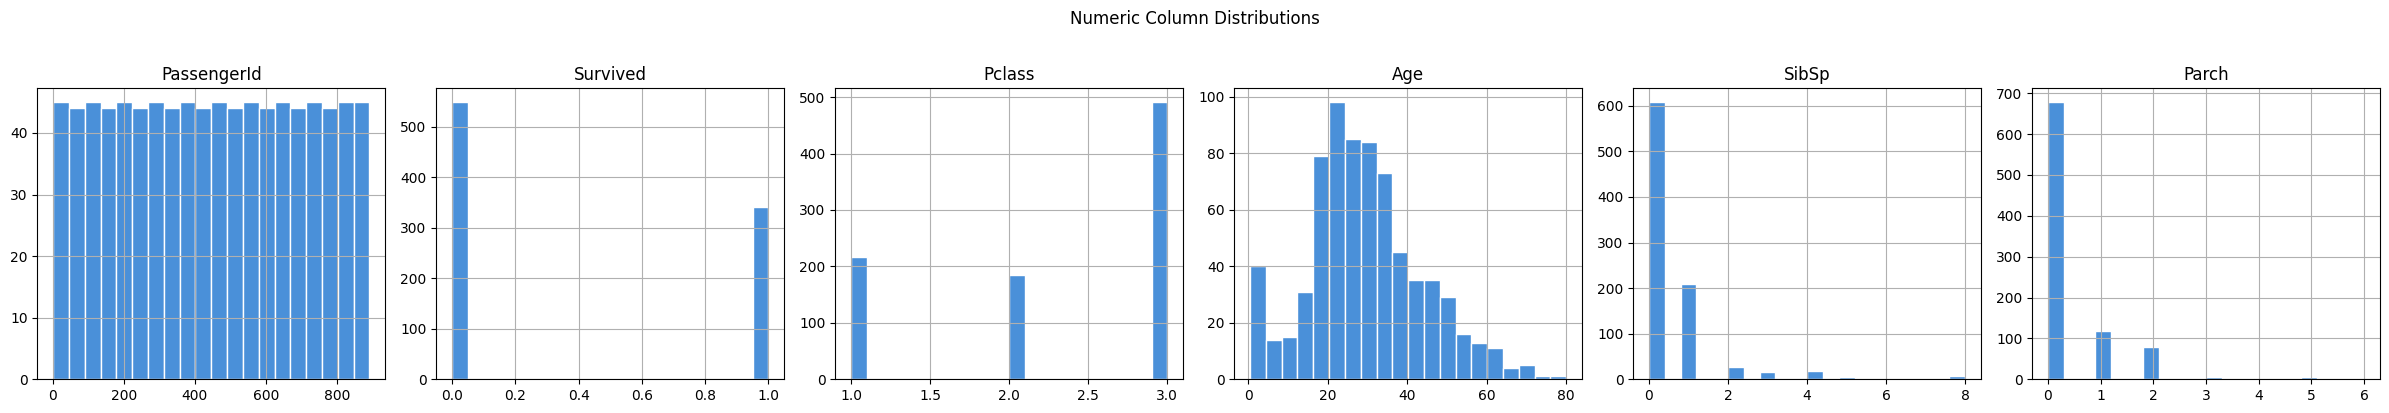


  → correlation


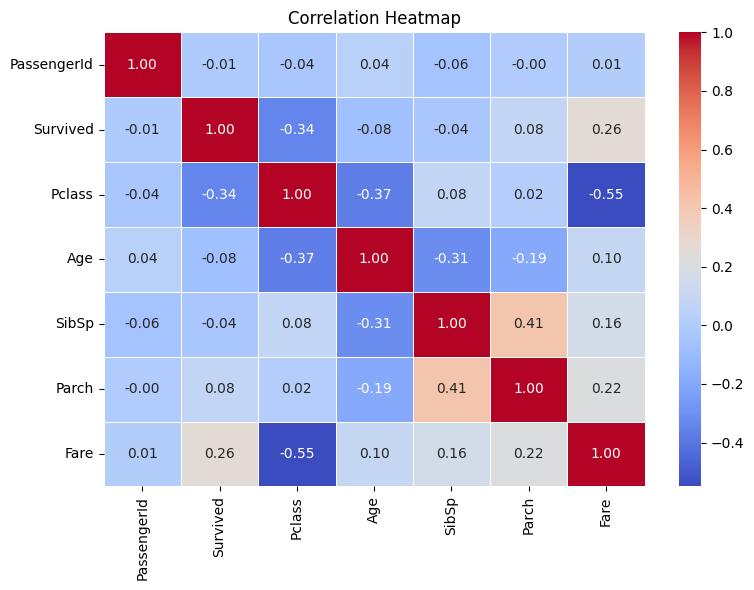


  → target_distribution


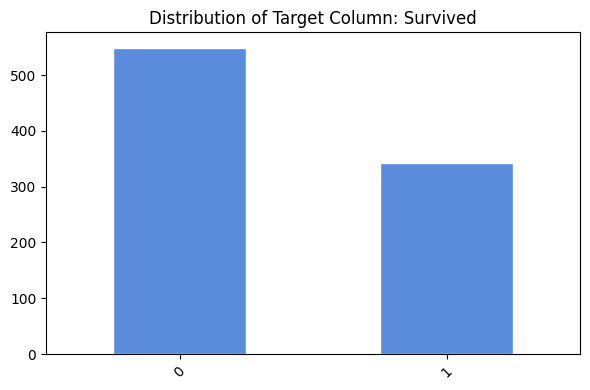

In [1]:
import sys
sys.path.append('..')
from ml_engine.eda import run_eda
import base64
from IPython.display import Image, display

# Run EDA on Titanic
eda_result = run_eda(
    csv_path   = '../storage/uploads/titanic.csv',
    target_col = 'Survived'
)

# Print overview
print("📋 OVERVIEW")
for k, v in eda_result['overview'].items():
    print(f"  {k:<20}: {v}")

# Print missing values
print("\n❗ MISSING VALUES")
if eda_result['missing']:
    for m in eda_result['missing']:
        print(f"  {m['column']:<15}: {m['missing']} missing ({m['percentage']}%)")
else:
    print("  No missing values!")

# Print numeric stats
print("\n📊 NUMERIC STATS")
for s in eda_result['stats']:
    print(f"  {s['column']:<15} mean={s['mean']}  median={s['median']}  min={s['min']}  max={s['max']}")

# Display all charts inline in the notebook
print("\n📈 CHARTS")
for chart_name, b64 in eda_result['charts'].items():
    print(f"\n  → {chart_name}")
    if isinstance(b64, str):
        img_bytes = base64.b64decode(b64.encode('utf-8'))
        display(Image(data=img_bytes))
    else:
        print(f"  skipping {chart_name} — not a valid string")

In [24]:
from predictor import predict

model_path = '../storage/models/model_test_job_001.pkl'

input_1 = {
    'Pclass'   : 3,
    'Sex'      : 'male',
    'Age'      : 40,
    'SibSp'    : 2,
    'Parch'    : 1,
    'Fare'     : 5,
    'Embarked' : 'S'
}

result_1 = predict(model_path, input_1)

# Print the RAW result first — see exactly what came back
print("Raw result:", result_1)

Raw result: {'status': 'success', 'task': 'classification', 'prediction': 1, 'label': '1', 'confidence': 56.21, 'model_used': 'LogisticRegression'}


In [26]:
from predictor import predict

# Path to the model we saved in Cell 6
model_path = '../storage/models/model_test_job_001.pkl'

# Test case 1: 1st class female — should predict Survived (1)
input_1 = {
    'Pclass'   : 1,
    'Sex'      : 'female',
    'Age'      : 28,
    'SibSp'    : 0,
    'Parch'    : 0,
    'Fare'     : 100,
    'Embarked' : 'S'
}

# Test case 2: 3rd class male — should predict Did not survive (0)
input_2 = {
    'Pclass'   : 3,
    'Sex'      : 'male',
    'Age'      : 22,
    'SibSp'    : 1,
    'Parch'    : 0,
    'Fare'     : 7.25,
    'Embarked' : 'S'
}

result_1 = predict(model_path, input_1)
result_2 = predict(model_path, input_2)

print("🧪 Test 1 — 1st class female:")
print(f"  Prediction  : {result_1['prediction']} ({result_1['label']})")
print(f"  Confidence  : {result_1['confidence']}%")
print(f"  Model used  : {result_1['model_used']}")

print("\n🧪 Test 2 — 3rd class male:")
print(f"  Prediction  : {result_2['prediction']} ({result_2['label']})")
print(f"  Confidence  : {result_2['confidence']}%")
print(f"  Model used  : {result_2['model_used']}")

🧪 Test 1 — 1st class female:
  Prediction  : 1 (1)
  Confidence  : 98.33%
  Model used  : LogisticRegression

🧪 Test 2 — 3rd class male:
  Prediction  : 1 (1)
  Confidence  : 91.43%
  Model used  : LogisticRegression


In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\saran\Desktop\Project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))
print(df['TotalCharges'].unique()[:20])

str
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str
<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str


In [2]:
import pandas as pd
import sys
sys.path.append('..')
from ml_engine.preprocessor import preprocess

df = pd.read_csv(r"C:\Users\saran\Desktop\Project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
X_train, X_test, y_train, y_test, feature_names, scaler, original_features = preprocess(df, 'Churn')
print("Feature Names:", feature_names)
print("X_train shape:", X_train.shape)

Feature Names: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
X_train shape: (5634, 29)
